In [1]:
import os,sys
import numpy as np
import pandas as pd
import scanpy as sc
from src import PATH

In [2]:
sc.set_figure_params(figsize=(4,3), dpi=80, frameon=False)

In [18]:
# load adata after QC
mul_adata = sc.read_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/multi_modal_filtered_Jan16.h5ad")

In [19]:
mul_adata

AnnData object with n_obs × n_vars = 90761 × 4000
    obs: 'UMI_counts', 'nascent_UMI_counts', 'nascent_ratio', 'target', 'target_genes', 'gRNA_UMI_counts', 'MT_ratio', 'nascent_MT_ratio', 'Cell_cycle_phase', 'whole_exon_ratio', 'new_exon_ratio', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'ontarget_sgRNA'
    varm: 'PCs'
    layers: 'Count_nascent_tx', 'Count_whole_tx'
    obsp: 'connectivities', 'distances'

/home/wergillius/.local/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


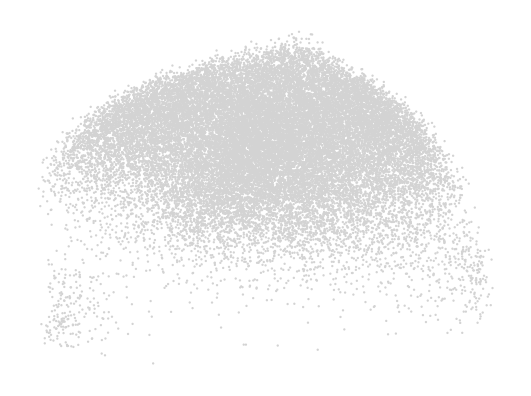

In [16]:
sc.pl.umap(mul_adata)

## normalize and visualize

In [23]:
n2000_hvg = mul_adata.var.dispersions_norm.nlargest(n=2000).index

In [25]:
mul_adata.raw = mul_adata
mul_adata = mul_adata[:, n2000_hvg]
mul_adata

View of AnnData object with n_obs × n_vars = 90761 × 2000
    obs: 'UMI_counts', 'nascent_UMI_counts', 'nascent_ratio', 'target', 'target_genes', 'gRNA_UMI_counts', 'MT_ratio', 'nascent_MT_ratio', 'Cell_cycle_phase', 'whole_exon_ratio', 'new_exon_ratio', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'ontarget_sgRNA'
    varm: 'PCs'
    layers: 'Count_nascent_tx', 'Count_whole_tx'
    obsp: 'connectivities', 'distances'

In [ ]:
mul_adata.write_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/n2000hvg_Apr15.h5ad")

## PCA

In [27]:
sc.tl.pca(mul_adata, svd_solver='arpack')

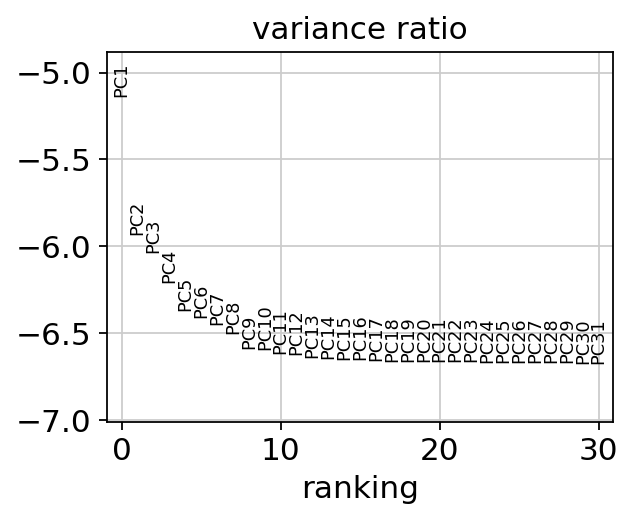

In [28]:
sc.pl.pca_variance_ratio(mul_adata, log=True)

In [29]:
sc.pp.neighbors(mul_adata, n_neighbors=50)

In [30]:
sc.tl.umap(mul_adata)

/home/wergillius/.local/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


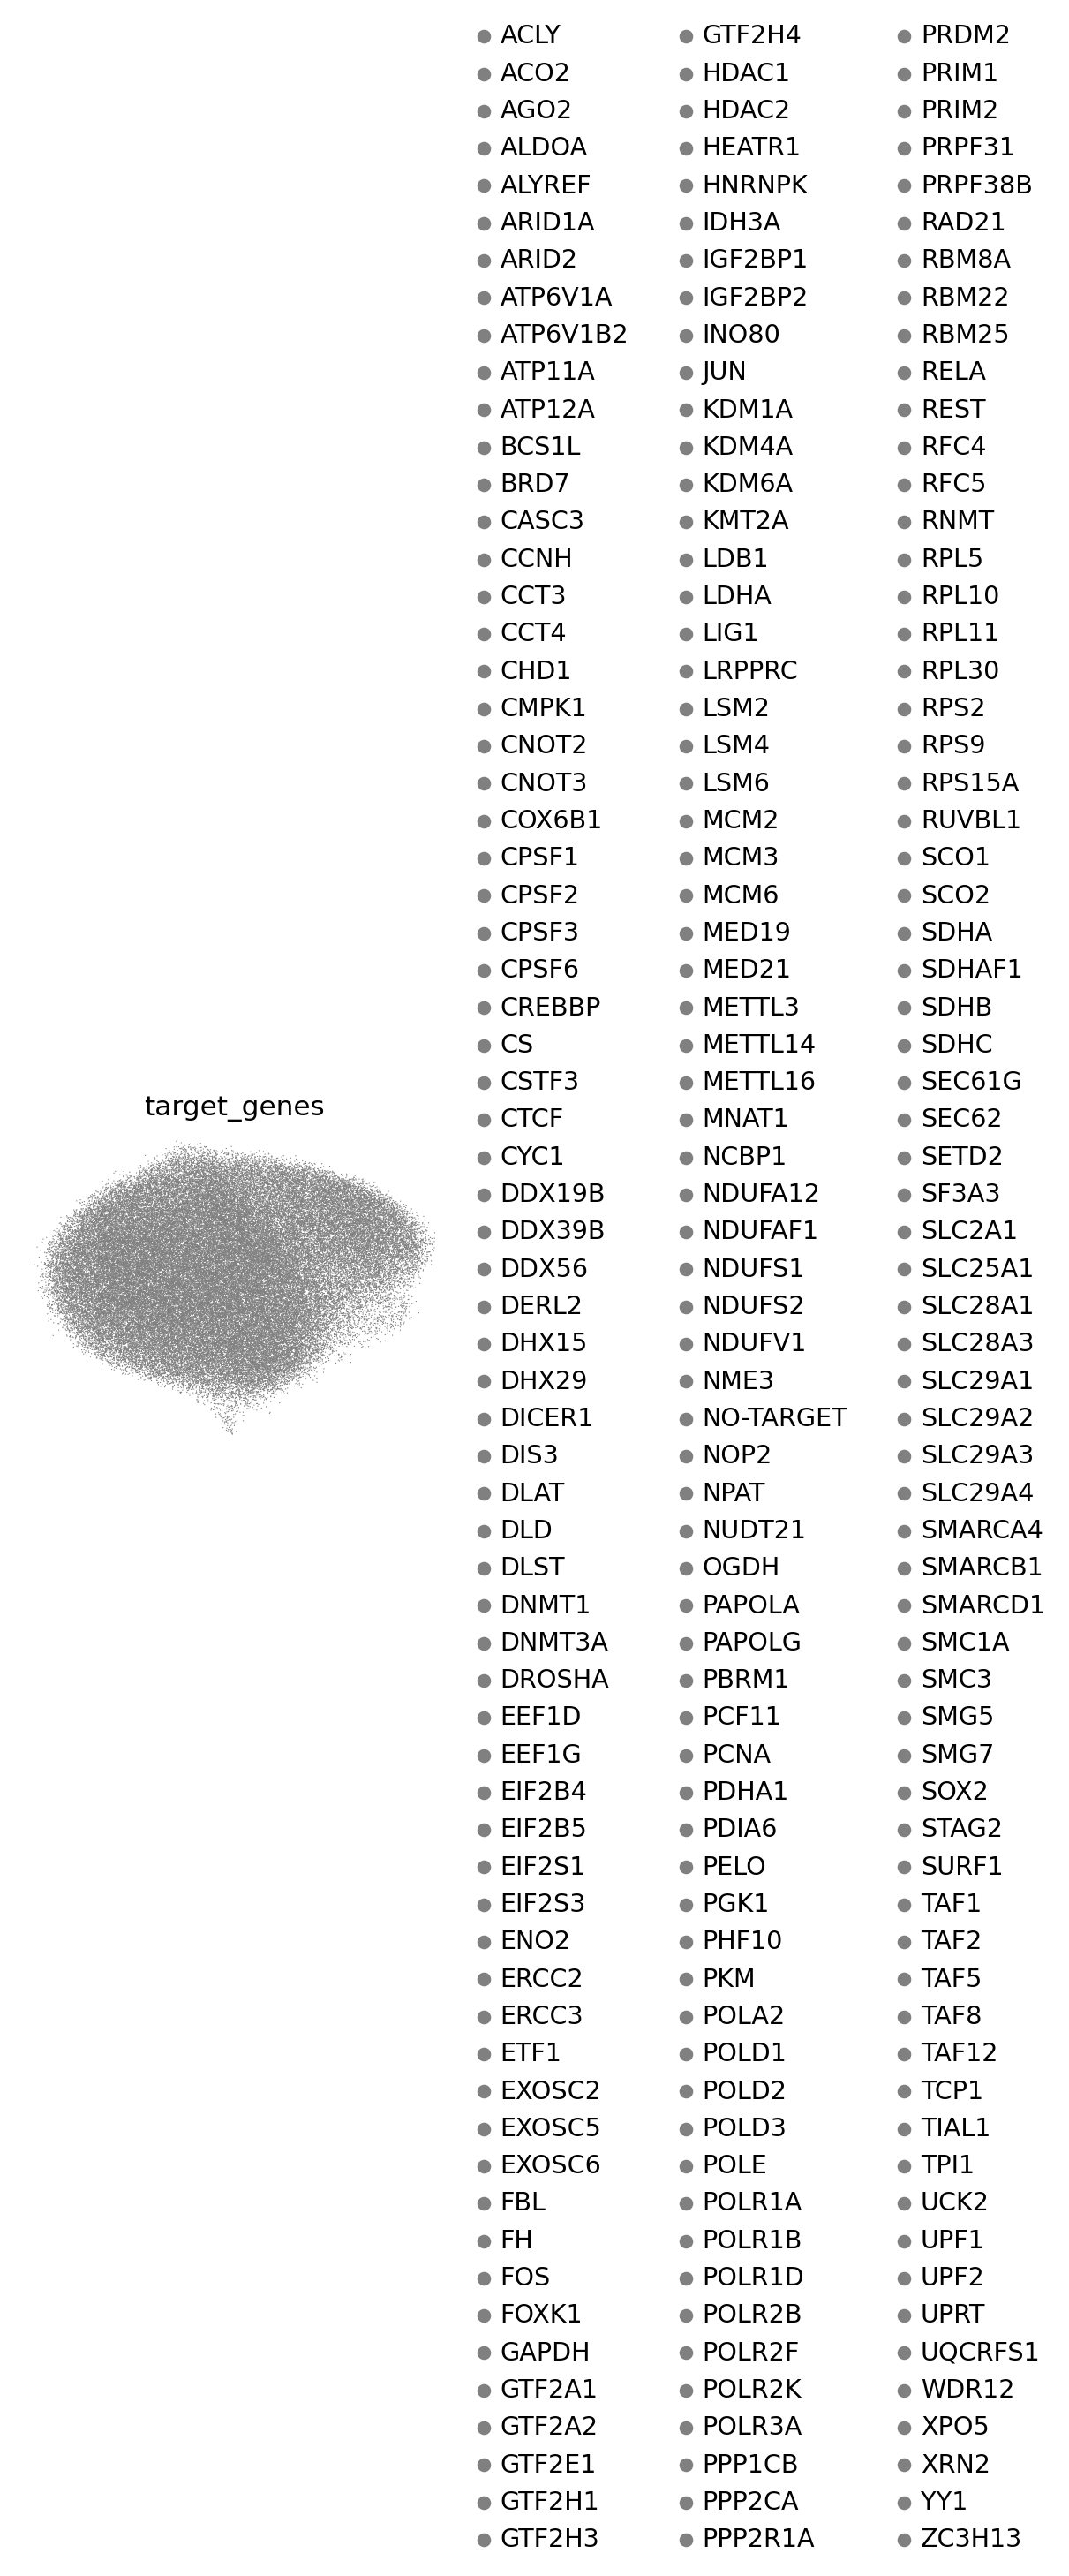

In [31]:
sc.pl.umap(mul_adata, color=['target_genes'])

In [32]:
sc.tl.leiden(mul_adata, resolution=0.8)

In [33]:
mul_adata.write_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/n2000hvg_Apr15.h5ad")

# **prepare the data for sampling**

In [ ]:
# TODO: prepare the `unique_token_dict`

In [41]:
with open('target_genes.txt', 'w') as f:
    for gene in mul_adata.obs.target_genes.cat.categories:
        f.write(gene+"\n")

In [40]:
with open('targets.txt', 'w') as f:
    for gene in mul_adata.obs.target.cat.categories:
        f.write(gene+"\n")

In [42]:
unique_token_dict = {g:i for i, g in enumerate(mul_adata.obs.target_genes.cat.categories)}

mul_adata.uns['unique_token_dict'] = unique_token_dict

count condition distribution

## filter out the dettached cells

/home/wergillius/.local/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


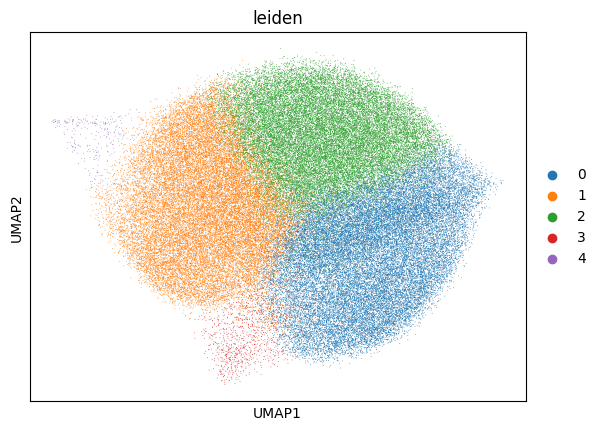

In [76]:
sc.pl.umap(mul_adata, color=['leiden'])

In [80]:
pure_cluster = ['0', '1', '2']
mul_adata_pure = mul_adata[mul_adata.obs.query("`leiden` in @pure_cluster").index].copy()

# **find root**

In [33]:
try:
#  if adata not loaded
    mul_adata_pure
except:
    mul_adata_pure = sc.read_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/d_preprocessed_Apr11.h5ad")

In [5]:
# find negative control (NC)
"NO-TARGET" in mul_adata.obs['target_genes'].values

True

In [34]:
mul_adata_pure.obs['is_control'] = mul_adata_pure.obs['target_genes'].values == "NO-TARGET"
mul_adata_pure.obs['is_control'] = mul_adata_pure.obs['is_control'].astype('category')

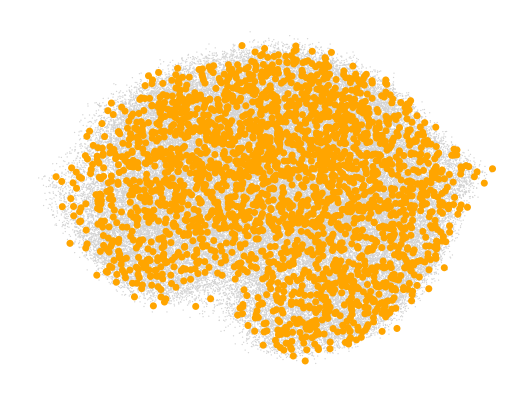

In [60]:
# check the distribution of control cell
control_cells = mul_adata_pure[mul_adata_pure.obs.is_control==True].copy()

fig = sc.pl.umap(mul_adata_pure, show=False, return_fig=True)
sc.pl.umap(control_cells, size=40, na_color='orange', ax=fig.gca())

In [83]:
control_cells.shape

(2522, 4000)

<font size=4 color='skyblue'> check the density of NC cells</font>

In [67]:
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats

<font size=4 color='darkgreen'>All cells

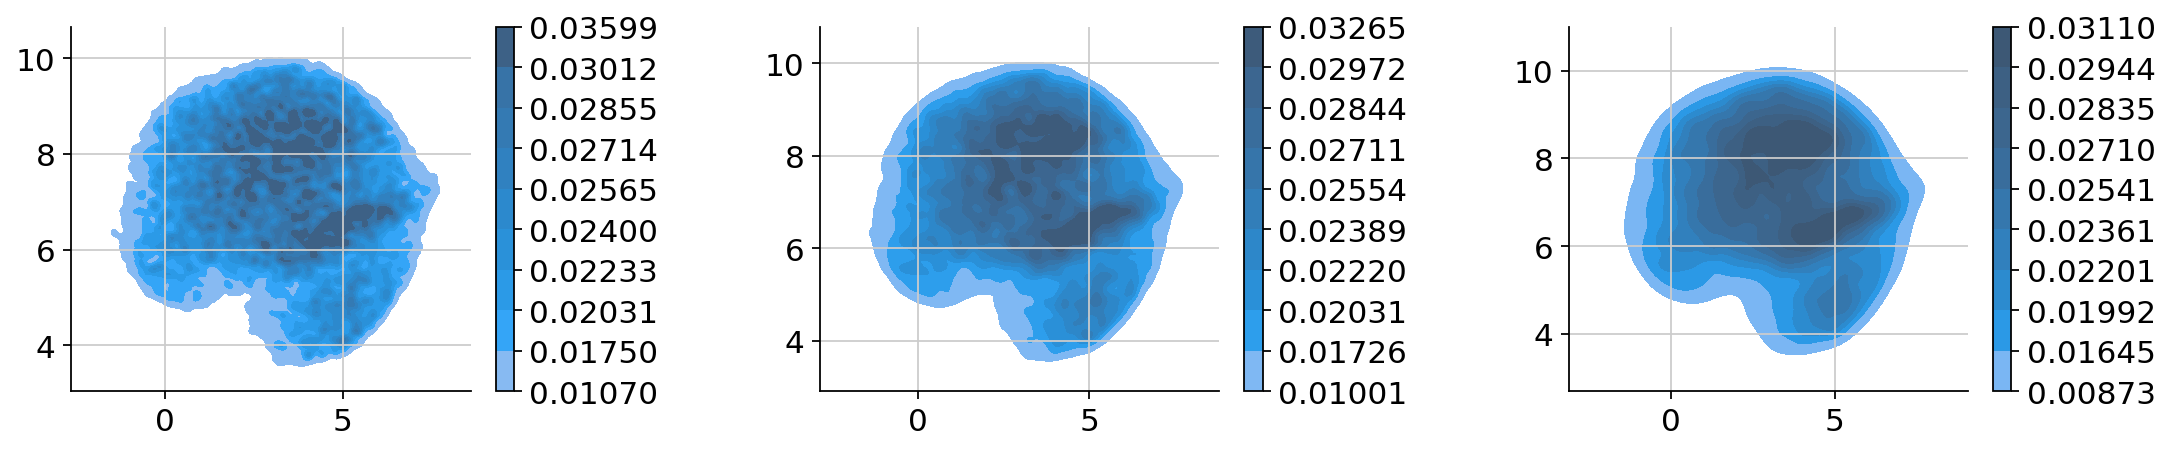

In [80]:
ucoords = mul_adata_pure.obsm['X_umap']

fig, axs = plt.subplots(1,3, figsize=(16,3), gridspec_kw={'wspace':0.5})

for i, bw in enumerate([0.3, 0.5, 0.8]):
    sns.kdeplot(x=ucoords[:,0], y=ucoords[:,1], fill=True, cbar=True, bw_adjust=bw, ax=axs[i])
    sns.despine(ax=axs[i])

<font size=4 color='darkgreen'>control cells

In [61]:
umap_coords = control_cells.obsm['X_umap']
print(umap_coords.shape)

(2522, 2)


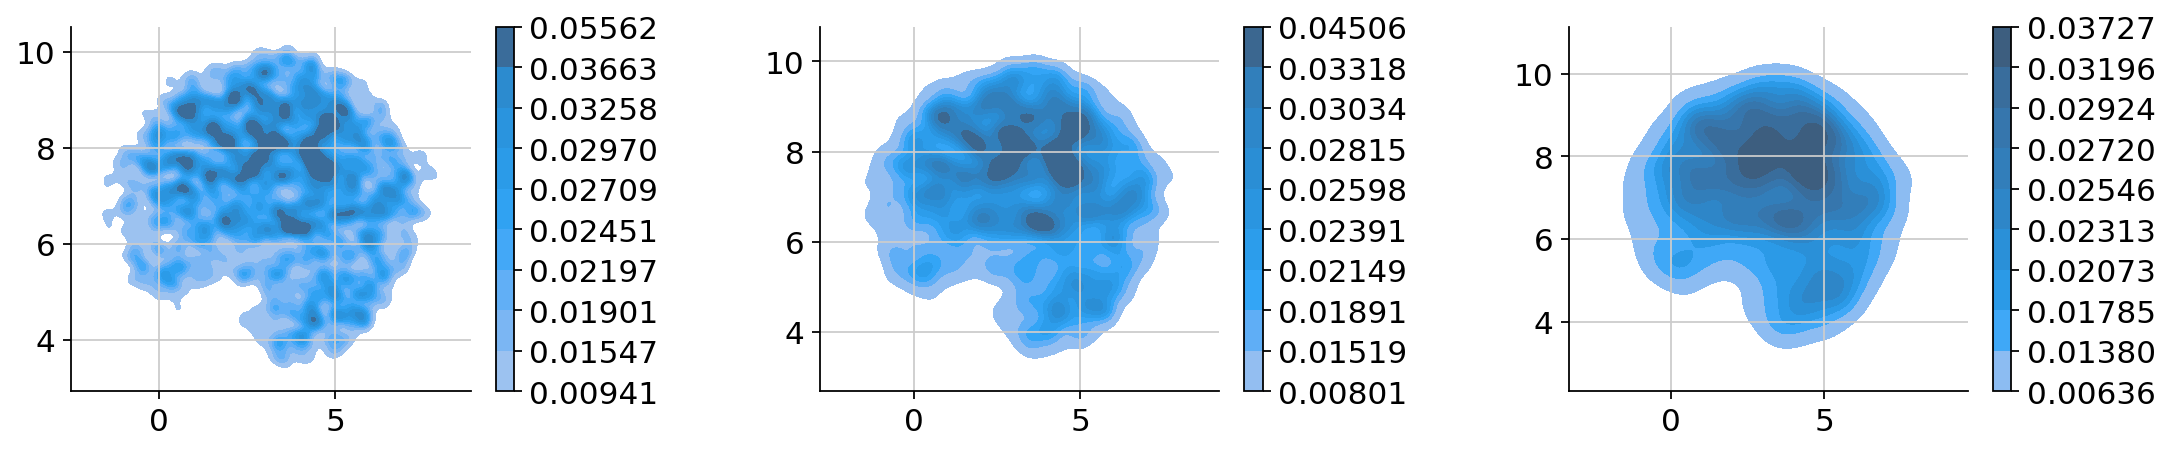

In [79]:
fig, axs = plt.subplots(1,3, figsize=(16,3), gridspec_kw={'wspace':0.5})

for i, bw in enumerate([0.3, 0.5, 0.8]):
    sns.kdeplot(x=umap_coords[:,0], y=umap_coords[:,1], fill=True, cbar=True, bw_adjust=bw, ax=axs[i])
    sns.despine(ax=axs[i])

## 

<font size=3 color='navy'>(Option 1) by **Mean** expression of NC cells</font>

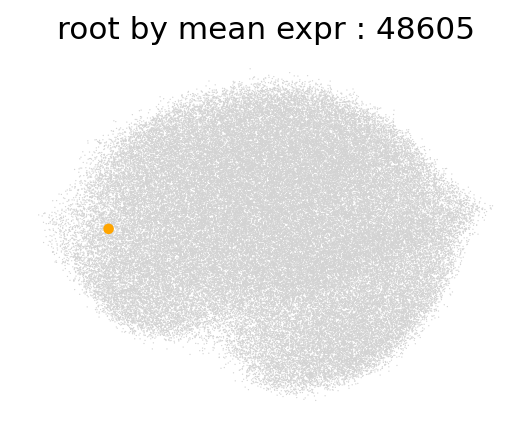

In [58]:
# mean expression of NC
mean_NC = control_cells.X.mean(axis=0)

# distance in expression space
MSE = np.sum((mul_adata_pure.X - mean_NC)**2, axis=1)
cb_root = np.argmin(MSE) 

# visualize
fig = sc.pl.umap(mul_adata_pure, show=False, return_fig=True)
sc.pl.umap(mul_adata_pure[cb_root], size=90, na_color='orange', ax=fig.gca(), title='root by mean expr : ' + str(cb_root))

<font size=3 color='orange'>(Option 2) by **Median** expression of NC cells</font>

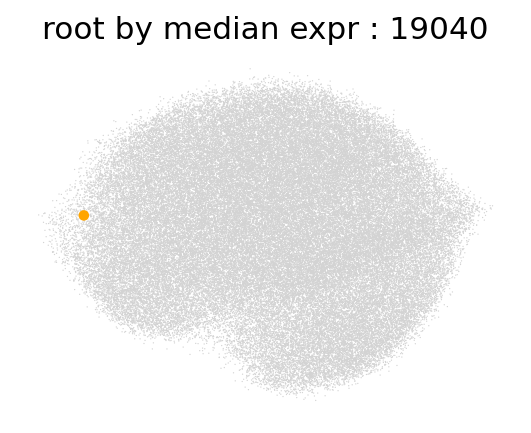

In [59]:
# median expression of NC
median_NC = np.median(control_cells.X.copy(), axis=0)

# distance in expression space
MSE = np.sum((mul_adata_pure.X - median_NC)**2, axis=1)
cb_root = np.argmin(MSE)


# the location in umap
fig = sc.pl.umap(mul_adata_pure, show=False, return_fig=True)
sc.pl.umap(mul_adata_pure[cb_root], size=90, na_color='orange', ax=fig.gca(), title = 'root by median expr : ' + str(cb_root))

# **compute pseudo-time by iroot**

In [63]:
mul_adata_pure.uns['iroot'] = 48605
cb_root = mul_adata_pure.obs_names[mul_adata_pure.uns['iroot']]

In [72]:
sc.tl.diffmap(mul_adata_pure, n_comps=10)

In [73]:
sc.tl.dpt(mul_adata_pure)

In [74]:
mul_adata_pure

AnnData object with n_obs × n_vars = 90761 × 4000
    obs: 'UMI_counts', 'nascent_UMI_counts', 'nascent_ratio', 'target', 'target_genes', 'gRNA_UMI_counts', 'MT_ratio', 'nascent_MT_ratio', 'Cell_cycle_phase', 'whole_exon_ratio', 'new_exon_ratio', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'dpt_pseudotime'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap', 'leiden', 'target_genes_colors', 'paga', 'leiden_sizes', 'unique_token_dict', 'iroot', 'diffmap_evals'
    obsm: 'X_pca', 'X_umap', 'ontarget_sgRNA', 'X_diffmap'
    varm: 'PCs'
    layers: 'Count_nascent_tx', 'Count_whole_tx'
    obsp: 'connectivities', 'distances'

# split train/ test and discretize the dpt

In [98]:
from src import _pp_fun as pp
from importlib import reload

In [99]:
reload(pp)

<module 'src._pp_fun' from '/home/wergillius/Project/diffuse_differentiate/src/_pp_fun.py'>

In [101]:
pp.infer_knn_depth(mul_adata_pure)

mul_adata_pure.obs['discrete_time'] = mul_adata_pure.obs['dpt_pseudotime'].apply(pp.discrete_time)

pp.random_split(mul_adata_pure)

mul_adata_pure.write_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/d_preprocessed_Apr11.h5ad")

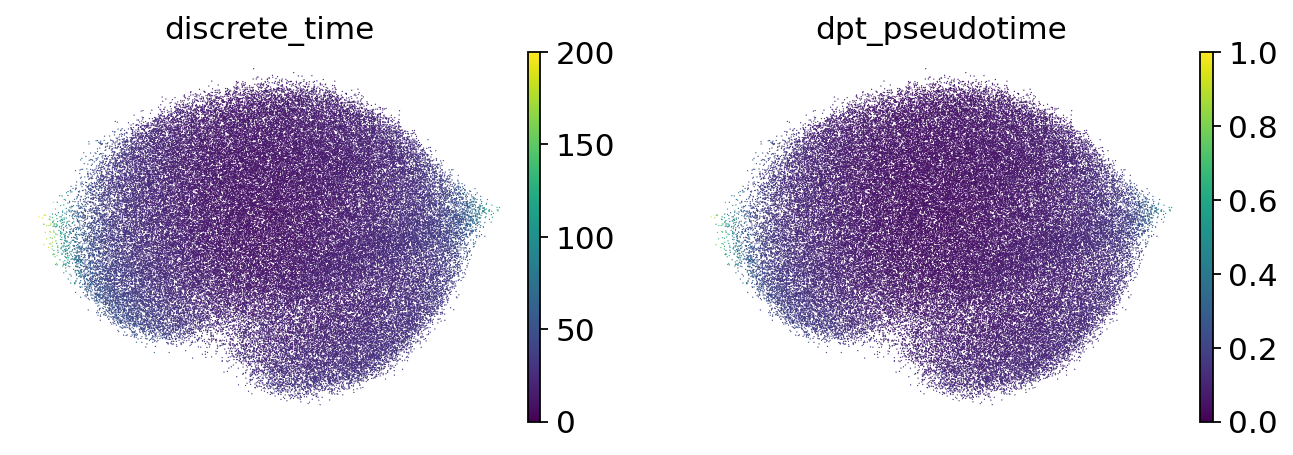

In [54]:
sc.pl.umap(mul_adata_pure, color=['discrete_time', 'dpt_pseudotime'])

In [96]:
pp.random_split(mul_adata)

In [97]:
mul_adata.obs['discrete_time'] = mul_adata.obs['dpt_pseudotime'].apply(pp.discrete_time)

mul_adata.write_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/Preprocessed_Apr11.h5ad")